In [164]:
from importlib import reload
import sys
import subprocess
import copy

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/pwg/Grad/Research/LMO/TES_thermal_model_qcyw/python/pymodelica.py'>

# Run the simualtion

In [165]:
MODEL_EXE_NAME = "System_LMO_exe"
MODEL_FILE = "../System_LMO.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"
MODEL_RESULT = f'../build/{MODEL_EXE_NAME}_res_init.mat'


EQUILIBRIUM_TIME = 20.0
PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
PARAMS_INIT = "../parameters/params_lmo_v1_mod_absorber_init.txt"

CINDEX_TARGET = 10
CINDEX_TARGETGOLD = 2


# Step 1. a fast simulation to reach equilibrium


-overrideFile=C:/Users/Tom/Documents/ThermalModel/parameters/params_lmo_v1_mod_absorber.txt

In [166]:
# Save a set of paramters with no excitation
config = pymodelica.read_config(PARAMS)
config_no_excitation = copy.copy(config)
config_no_excitation["Edep"] = 0
pymodelica.write_config(PARAMS_INIT,config_no_excitation)

log = subprocess.run(
    [
        f"./{MODEL_EXE_NAME}.exe",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-3",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_EXE_NAME}_res_init.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
        '-deltaXLinearize=1e-9'
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log.stderr, log.stdout


('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

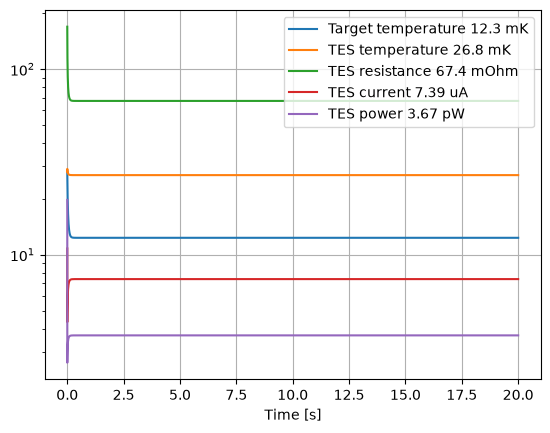

In [167]:
# Plot all C and G to check if the system is at equilibrium
filename_init = f'../build/{MODEL_EXE_NAME}_res_init.mat'
time_steps_init, data_init = pymodelica.load(filename_init)

y = data_init['T10']*1e3
plt.plot(time_steps_init, y, label=f"Target temperature {y[-1]:.3g} mK")
y = data_init['T1']*1e3
plt.plot(time_steps_init, y, label=f"TES temperature {y[-1]:.3g} mK")
y = data_init['c1.R']*1e3
plt.plot(time_steps_init, y, label=f"TES resistance {y[-1]:.3g} mOhm")
y = data_init['c1.i']*1e6
plt.plot(time_steps_init, y, label=f"TES current {y[-1]:.3g} uA")
y = data_init['c1.i']**2*data_init['c1.R']*1e12
plt.plot(time_steps_init, y, label=f"TES power {y[-1]:.3g} pW")
plt.legend()
plt.xlabel("Time [s]")
plt.grid()
plt.yscale("log")


In [168]:
pymodelica.mod_svg("../System_LMO.svg", "temp_image.svg", data_init, system_name="System_LMO", width=1200, display=True)

## Step 1b. Noise and Complex impedance

In [182]:
reload(pymodelica)

<module 'pymodelica' from '/mnt/c/Users/pwg/Grad/Research/LMO/TES_thermal_model_qcyw/python/pymodelica.py'>

In [187]:
model = pymodelica.TESModel(MODEL_FILE_LIN, 
                 MODEL_FILE, 
                 MODEL_RESULT,
                 config = {},
                 f_min = 1, f_max = 1000e3, points = 1000)

frequencies, noise_current = model.get_noise(
    Rsh_temperature = 0.2,
    # Rp_temperature = 0.2,
    noise_electronics = 4.2e-12,
    noise_flicker_corner = 20,
    noise_flicker_gamma = 1,
    index_cinput = CINDEX_TARGET)

resolution_1 = model.get_resolution(index_cinput = CINDEX_TARGET)

resolution_split = model.get_resolution_split(
    index_cinput1 = CINDEX_TARGET, 
    index_cinput2 = CINDEX_TARGETGOLD, 
    fraction_1 = config["Edep_fractiontarget"],
    fmin = 60,
    fmax = 1e5)

print("Target referred resolution:", resolution_1)
print("Input referred resolution:", resolution_split)

Target referred resolution: 909.5621640248655
Input referred resolution: 453.9265551642941


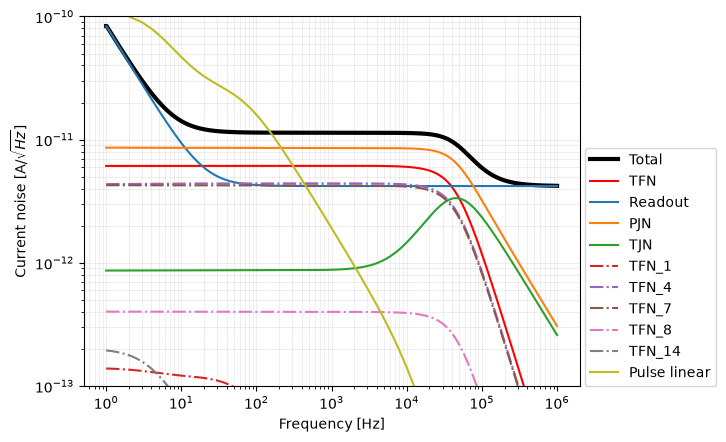

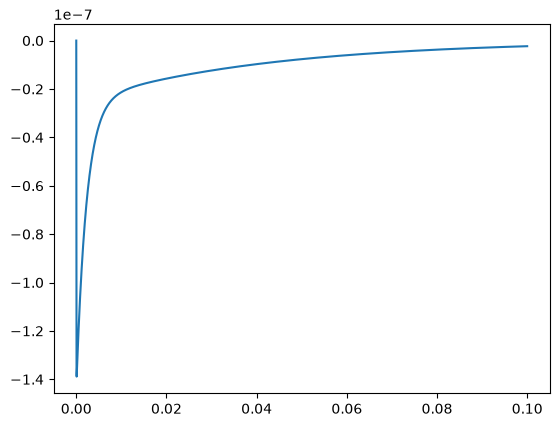

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='Frequency [Hz]', ylabel='|$Z_{circ}$| [$\\Omega$]'>,
        <Axes: xlabel='Real($Z_{circ}$) [$\\Omega$]', ylabel='Imag($Z_{circ}$) [$\\Omega$]'>],
       dtype=object))

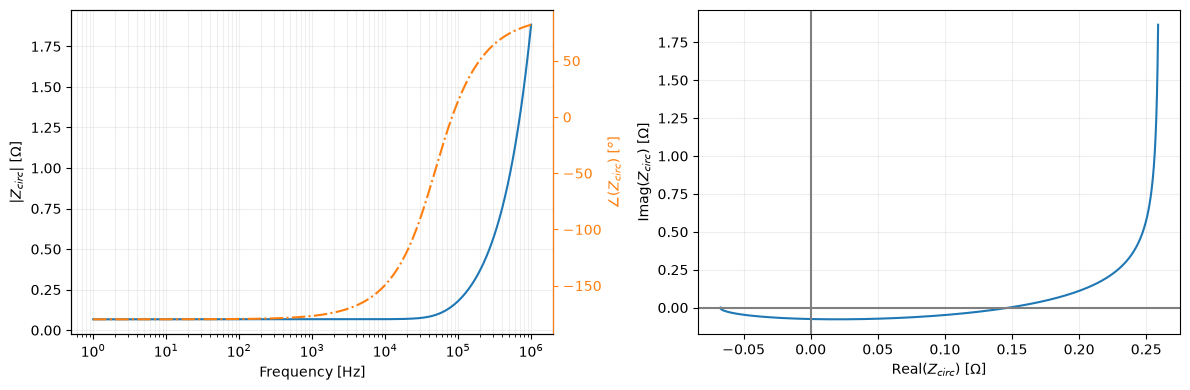

In [171]:
t_linear, y_linear = model.get_impulse_split(index_cinput1 = 10, index_cinput2 = 2, 
                              fraction_1 = config["Edep_fractiontarget"], 
                              scale_ev = config["Edep"], 
                              T=np.linspace(0,1,100_000))

# Noise
model.plot_noise_current()
fy, y_fft = scipy.signal.periodogram(y_linear[:, 1]*0.06, fs=1/(t_linear[1]-t_linear[0]))  # Add pulse to the noise plot
plt.plot(fy, np.sqrt(y_fft), label="Pulse linear")
plt.legend(loc=(1.01,0))
plt.show()


# Impulse response
mask = t_linear<0.1
plt.plot(t_linear[mask], y_linear[:,1][mask])
plt.show()

# Impedance
model.plot_impedance()


# Step 2: impulse response

Compile another simulation with fine resolution starting from the final values of Step 1

In [172]:

# Using -iif (Import Initial File) and -iit (Import Initial Time) to reset startTime = 0.0
log2 = subprocess.run(
    [
        f"./{MODEL_EXE_NAME}.exe",
        f"-r={MODEL_EXE_NAME}_res_final.mat",
        f"-overrideFile={PARAMS}",
        "-s=dassl",
        "-w",
        "-startTime=0",
        "-stopTime=0.4",
        "-stepSize=3e-6",
        "-tolerance=1e-8",
        f"-iif={MODEL_EXE_NAME}_res_init.mat",
        f"-iit={EQUILIBRIUM_TIME}",
        "-lv=-LOG_STDOUT",
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log2.stderr, log2.stdout

('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [181]:
filename = f'../build/{MODEL_EXE_NAME}_res_final.mat'

time_steps, data = pymodelica.load(filename)

In [175]:
pymodelica.get_collection_efficiency(time_steps, data, 200e3, 1)

Collection Efficiency is  0.977%


np.float64(0.9774117455957396)

(-0.01, 0.4)

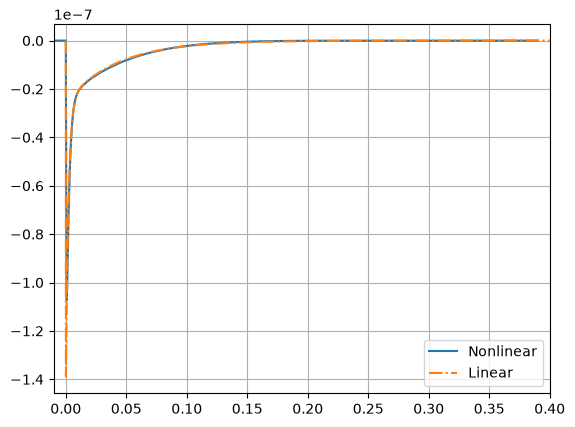

In [177]:
y_nonlinear = data['c1.i'] - np.mean(data['c1.i'][:10])
plt.plot(time_steps-0.01, y_nonlinear, label="Nonlinear")
plt.plot(t_linear, y_linear[:,1], label="Linear", linestyle="-.")
plt.legend()
plt.grid()
plt.xlim(-0.01,0.4)

### Get resolution of the non-linear model

In [178]:
fy, psd = scipy.signal.periodogram(y_nonlinear/(200e3*1.6e-19), fs=1/(time_steps[1]-time_steps[0]))
dIdP = np.interp(model.frequencies, fy, np.sqrt(psd/2))

resolution_nonlinear = model.get_resolution(dIdP)
print(resolution_nonlinear)


212.93421794039713


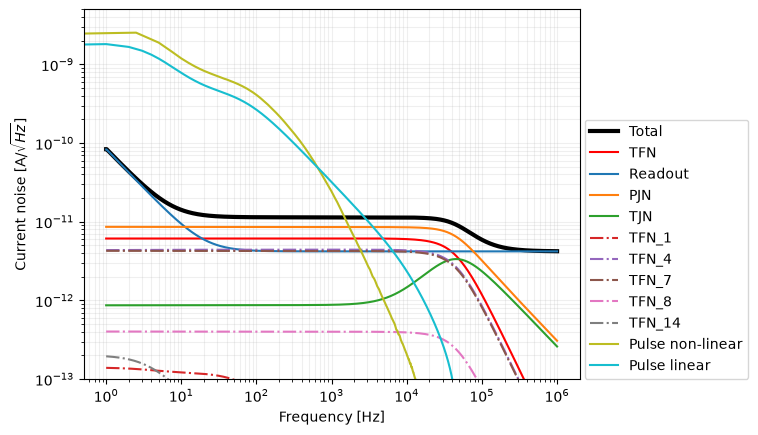

In [179]:
model.plot_noise_current()

fy, y_fft = scipy.signal.periodogram(y_nonlinear, fs=1/(time_steps[1]-time_steps[0]))
plt.plot(fy, np.sqrt(y_fft), label="Pulse non-linear")

fs=1/(t_linear[1]-t_linear[0])
fy, y_fft = scipy.signal.periodogram(y_linear[:,1], fs=1/(t_linear[1]-t_linear[0]))
plt.plot(fy, np.sqrt(y_fft), label="Pulse linear")
plt.ylim(1e-13, 5e-9)
plt.legend(loc=(1.01,0))


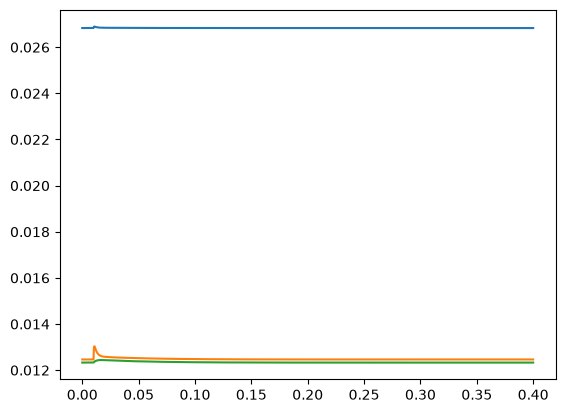

In [180]:
plt.plot(time_steps, data['T1'])
plt.plot(time_steps, data['T2'])
plt.plot(time_steps, data['T10'])